# Chapter 17 — Correlation Analysis

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain how correlation extends covariance
- Calculate and interpret Pearson's correlation coefficient
- Understand why correlation is standardized between -1 and +1
- Distinguish the direction and strength of a linear relationship
- Calculate correlation manually and with pandas and SciPy
- Read a correlation matrix
- Understand the effect of changing measurement units
- Recognize nonlinear patterns and the effect of outliers
- Distinguish correlation from causation


## 1. From Covariance to Correlation

In Chapter 16, we learned that covariance describes whether two quantitative variables tend to move together.

However, covariance has an important limitation:

> Its magnitude depends on the units and scales of the variables.

Correlation solves this problem by standardizing covariance.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing a data/ directory.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "17_correlation_analysis.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,employee_id,training_hours,performance_score,experience_years,commute_minutes
0,E001,7.9,85.0,2.8,39.8
1,E002,9.0,74.5,1.2,11.5
2,E003,5.4,76.7,6.2,39.8
3,E004,0.8,61.1,6.6,57.2
4,E005,3.0,51.7,0.3,24.4


## 2. Dataset

The dataset contains **80 fictional employees**.

| Variable | Description |
|---|---|
| `employee_id` | Fictional employee identifier |
| `training_hours` | Training hours |
| `performance_score` | Performance assessment score |
| `experience_years` | Years of work experience |
| `commute_minutes` | Commute time in minutes |

All data are synthetic and are used only for statistical learning.


In [2]:
df.describe()


,training_hours,performance_score,experience_years,commute_minutes
count,80.000000,80.000000,80.000000,80.000000
mean,6.217500,73.007500,6.117500,38.126250
std,3.419185,12.750327,3.586182,14.973747
min,0.500000,40.000000,0.300000,5.000000
25%,3.300000,63.025000,2.800000,29.350000
50%,5.950000,74.300000,6.350000,36.350000
75%,9.375000,82.125000,9.350000,47.725000
max,12.000000,100.000000,12.000000,85.600000


## 3. Begin with a Scatter Plot

Correlation should not be interpreted without first looking at the data.


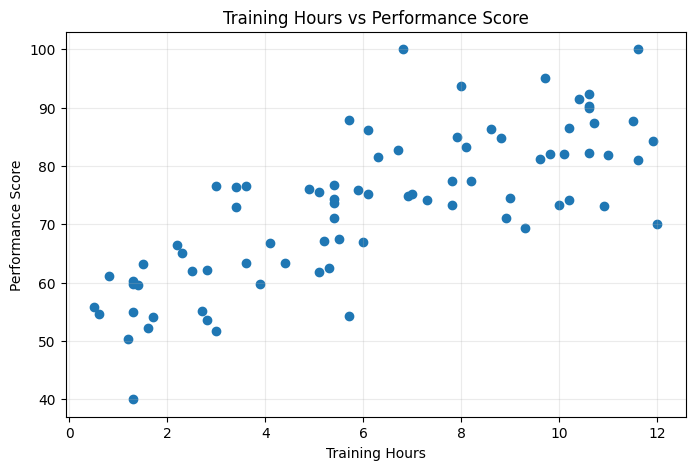

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["training_hours"], df["performance_score"])
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.title("Training Hours vs Performance Score")
plt.grid(alpha=0.25)
plt.show()


The scatter plot suggests a positive linear relationship: employees with more training hours tend to have higher performance scores.


## 4. Pearson's Correlation Coefficient

Pearson's correlation coefficient standardizes covariance:

$$
r =
\frac{s_{XY}}{s_X s_Y}
$$

where:

- $s_{XY}$ is the sample covariance between $X$ and $Y$
- $s_X$ is the sample standard deviation of $X$
- $s_Y$ is the sample standard deviation of $Y$

Because covariance is divided by the product of the two standard deviations, Pearson's $r$ is unitless.


## 5. Range of the Correlation Coefficient

Pearson's correlation coefficient always satisfies

$$
-1 \le r \le 1
$$

Interpretation of the sign:

- $r > 0$: positive linear relationship
- $r < 0$: negative linear relationship
- $r \approx 0$: little or no **linear** relationship

The absolute value $|r|$ describes the strength of the linear association.

Values closer to 1 indicate a stronger linear pattern; values closer to 0 indicate a weaker linear pattern.

There is no universal rule that makes one numerical cutoff appropriate for every field or dataset.


## 6. Calculate Pearson's r from Covariance

Let's calculate the correlation between training hours and performance score using the relationship from Chapter 16.


In [4]:
x = df["training_hours"]
y = df["performance_score"]

cov_xy = x.cov(y)
sd_x = x.std(ddof=1)
sd_y = y.std(ddof=1)

manual_r = cov_xy / (sd_x * sd_y)

print("Covariance:", cov_xy)
print("SD of X:", sd_x)
print("SD of Y:", sd_y)
print("Pearson r:", manual_r)


Covariance: 33.36872784810126
SD of X: 3.4191854459686812
SD of Y: 12.750326627734838
Pearson r: 0.7654127342600723


This calculation shows the bridge between the two chapters:

$$
\text{Covariance}
\quad \longrightarrow \quad
\text{Standardize by } s_X s_Y
\quad \longrightarrow \quad
\text{Correlation}
$$


## 7. Correlation with pandas


In [5]:
pandas_r = df["training_hours"].corr(df["performance_score"])
pandas_r


np.float64(0.7654127342600722)

In [6]:
np.isclose(manual_r, pandas_r)


np.True_

The manual calculation and `pandas.Series.corr()` should agree apart from floating-point rounding.


## 8. Correlation with SciPy

SciPy provides `pearsonr()`, which returns both the correlation coefficient and a p-value for testing a null hypothesis of zero population correlation.


In [7]:
pearson_result = stats.pearsonr(
    df["training_hours"],
    df["performance_score"]
)

pearson_result


PearsonRResult(statistic=np.float64(0.7654127342600725), pvalue=np.float64(1.3668583787375095e-16))

The coefficient describes the observed linear association.

The p-value addresses a different question: whether the data provide evidence against a population correlation of zero under the assumptions of the test.

A small p-value does not tell us that the relationship is practically important, and it does not establish causation.


## 9. Correlation Matrix

For several quantitative variables, we can calculate all pairwise Pearson correlations at once.


In [8]:
numeric_cols = [
    "training_hours",
    "performance_score",
    "experience_years",
    "commute_minutes"
]

corr_matrix = df[numeric_cols].corr()
corr_matrix


,training_hours,performance_score,experience_years,commute_minutes
training_hours,1.000000,0.765413,-0.238576,-0.174242
performance_score,0.765413,1.000000,-0.271635,-0.053333
experience_years,-0.238576,-0.271635,1.000000,0.300336
commute_minutes,-0.174242,-0.053333,0.300336,1.000000


The diagonal is always 1 because each variable is perfectly correlated with itself.

The matrix is symmetric:

$$
r_{XY} = r_{YX}
$$


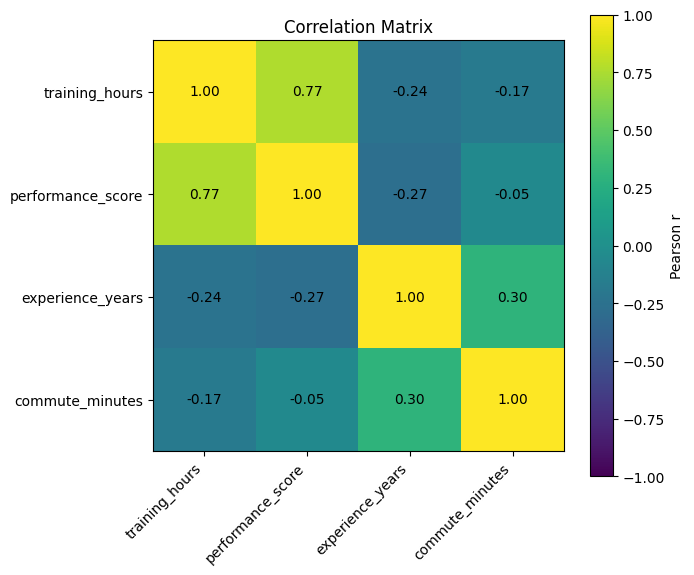

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 10. Correlation Is Unchanged by Positive Unit Conversion

In Chapter 16, changing hours to minutes changed covariance.

Now convert training hours to training minutes and calculate the correlation again.


In [10]:
df["training_minutes"] = df["training_hours"] * 60

r_hours = df["training_hours"].corr(df["performance_score"])
r_minutes = df["training_minutes"].corr(df["performance_score"])

print("Correlation using hours:", r_hours)
print("Correlation using minutes:", r_minutes)


Correlation using hours: 0.7654127342600722
Correlation using minutes: 0.7654127342600728


The correlation is unchanged.

Multiplying a variable by a positive constant changes its scale, but it does not change Pearson's correlation coefficient.

This is one major advantage of correlation over raw covariance.


## 11. Positive, Negative, and Near-Zero Correlation

Let's create three simple illustrative patterns.


In [11]:
rng = np.random.default_rng(42)
x_demo = np.linspace(0, 10, 50)

positive_y = 2 * x_demo + rng.normal(0, 2, 50)
negative_y = -2 * x_demo + rng.normal(0, 2, 50)
none_y = rng.normal(0, 6, 50)

demo = pd.DataFrame({
    "x": x_demo,
    "positive": positive_y,
    "negative": negative_y,
    "near_zero": none_y
})

demo.corr()["x"]


x            1.000000
positive     0.971666
negative    -0.971763
near_zero    0.039571
Name: x, dtype: float64

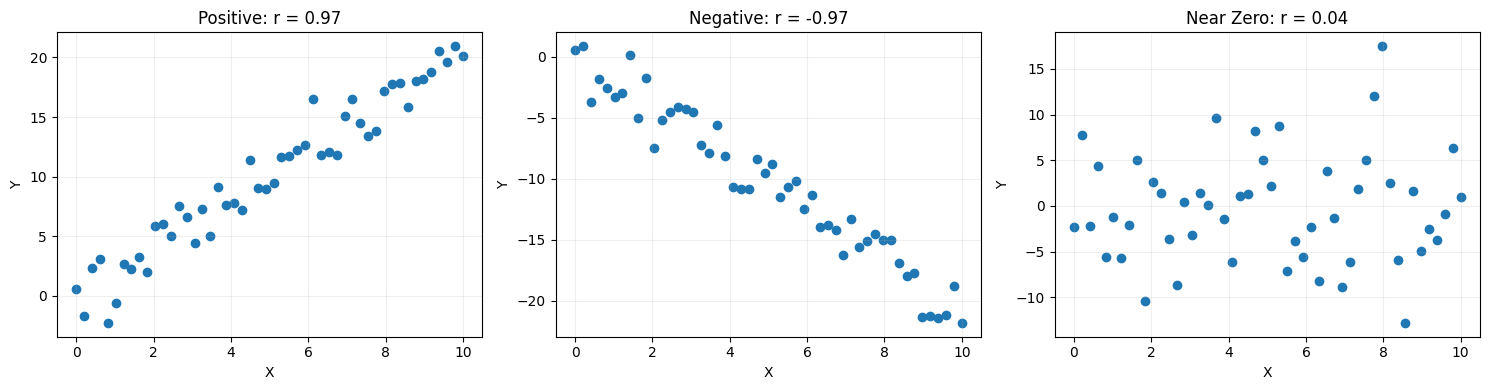

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(demo["x"], demo["positive"])
axes[0].set_title(f"Positive: r = {demo['x'].corr(demo['positive']):.2f}")

axes[1].scatter(demo["x"], demo["negative"])
axes[1].set_title(f"Negative: r = {demo['x'].corr(demo['negative']):.2f}")

axes[2].scatter(demo["x"], demo["near_zero"])
axes[2].set_title(f"Near Zero: r = {demo['x'].corr(demo['near_zero']):.2f}")

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 12. Correlation Measures Linear Association

A correlation near zero does not necessarily mean that two variables are unrelated.

Consider the nonlinear relationship

$$
Y = X^2
$$


Pearson r: -1.2308082219636655e-16


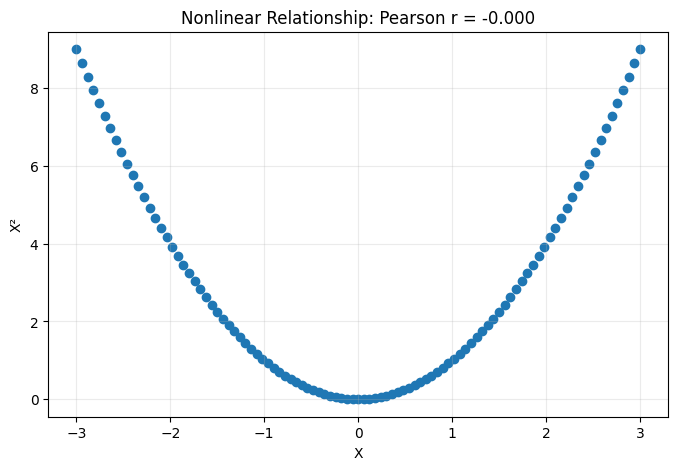

In [13]:
x_curve = np.linspace(-3, 3, 101)
y_curve = x_curve ** 2

r_curve = np.corrcoef(x_curve, y_curve)[0, 1]
print("Pearson r:", r_curve)

plt.figure(figsize=(8, 5))
plt.scatter(x_curve, y_curve)
plt.xlabel("X")
plt.ylabel("X²")
plt.title(f"Nonlinear Relationship: Pearson r = {r_curve:.3f}")
plt.grid(alpha=0.25)
plt.show()


There is a clear relationship, but it is not linear.

Pearson's correlation coefficient is specifically a measure of **linear association**.

This is why visualizing the data is essential.


## 13. Correlation Can Be Sensitive to Outliers

A single unusual observation can substantially change Pearson's correlation coefficient.

Let's examine a simple example.


In [14]:
rng = np.random.default_rng(7)

x_outlier = np.arange(1, 21)
y_outlier = rng.normal(10, 2, 20)

r_before = np.corrcoef(x_outlier, y_outlier)[0, 1]

x_with = np.append(x_outlier, 35)
y_with = np.append(y_outlier, 40)

r_after = np.corrcoef(x_with, y_with)[0, 1]

print("Correlation before outlier:", r_before)
print("Correlation after outlier:", r_after)


Correlation before outlier: -0.3343190801950486
Correlation after outlier: 0.6084625698928798


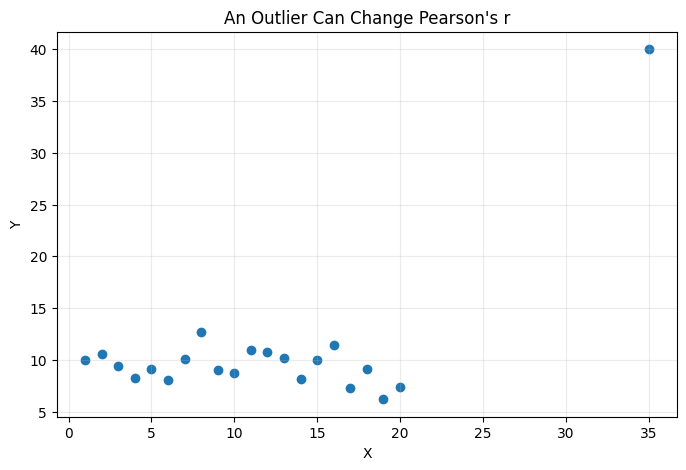

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(x_with, y_with)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("An Outlier Can Change Pearson's r")
plt.grid(alpha=0.25)
plt.show()


The lesson is not to automatically delete unusual observations.

Instead:

1. inspect the observation,
2. check whether it is a data error,
3. understand whether it belongs to the population of interest,
4. report sensitivity when appropriate.


## 14. Correlation Does Not Imply Causation

Correlation describes association, not causal direction.

If two variables are correlated, several explanations may be possible:

- X may influence Y
- Y may influence X
- a third variable may influence both
- the pattern may arise from selection, measurement, or chance

Establishing causality requires research design and additional assumptions beyond a correlation coefficient.


## 15. A Practical Workflow for Correlation Analysis

A useful workflow is:

$$
\text{Choose Quantitative Variables}
\rightarrow
\text{Inspect Scatter Plot}
\rightarrow
\text{Calculate Pearson's } r
\rightarrow
\text{Check Outliers and Nonlinearity}
\rightarrow
\text{Interpret Direction and Strength}
\rightarrow
\text{Avoid Causal Claims}
$$


## 16. Exercises

### Exercise 1
Calculate Pearson's correlation between `experience_years` and `performance_score`.

Describe the direction and observed strength without relying on a rigid universal cutoff.

### Exercise 2
Calculate the correlation between `training_hours` and `commute_minutes`.

Create a scatter plot and compare the visual pattern with the numerical coefficient.

### Exercise 3
Calculate the covariance between `training_hours` and `performance_score`, then reproduce Pearson's $r$ manually.

### Exercise 4
Convert `performance_score` by multiplying every value by 10.

Compare:

- the covariance before and after the conversion
- the correlation before and after the conversion

### Exercise 5
Create your own nonlinear variables where Pearson's $r$ is close to zero even though a clear relationship exists.

### Exercise 6
Add one extreme observation to two weakly related variables and observe how Pearson's $r$ changes.


## 17. Summary

Correlation standardizes covariance so that linear relationships can be compared across different measurement scales.

The central relationship is

$$
r =
\frac{s_{XY}}{s_X s_Y}
$$

Key points:

- Pearson's $r$ ranges from -1 to +1
- the sign describes the direction of the linear relationship
- $|r|$ describes the observed strength of the linear association
- correlation is unitless
- positive unit conversions do not change Pearson's $r$
- $r \approx 0$ does not rule out nonlinear relationships
- outliers can strongly affect Pearson's $r$
- correlation does not imply causation
- scatter plots should accompany correlation coefficients

### Next Chapter

**Chapter 18 — Simple Linear Regression**

Correlation describes the strength and direction of a linear relationship.

Regression takes the next step by modeling how an outcome variable changes with a predictor.
